In [1]:
import pandas as pd
import numpy as np
import os

# RELOAD DATA (CSV only - no parquet needed)
if os.path.exists('../data/ni_imd_clean.csv'):
    ni_imd = pd.read_csv('../data/ni_imd_clean.csv')
    print("Loaded from CSV")
else:
    # Full reload from raw CSV
    df = pd.read_csv('../data/ibtracs.NI.list.v04r01.csv', low_memory=False)
    ni_imd = df[
        df['NEWDELHI_LAT'].notna() & 
        df['NEWDELHI_LON'].notna() & 
        (pd.to_datetime(df['ISO_TIME'], errors='coerce') >= '1982-01-01')
    ].copy()
    ni_imd['time'] = pd.to_datetime(ni_imd['ISO_TIME'], errors='coerce')
    ni_imd['lon'] = pd.to_numeric(ni_imd['NEWDELHI_LON'], errors='coerce')
    ni_imd['lat'] = pd.to_numeric(ni_imd['NEWDELHI_LAT'], errors='coerce')
    ni_imd = ni_imd.dropna(subset=['lon', 'lat'])
    ni_imd.to_csv('../data/ni_imd_clean.csv', index=False)  # ✅ CSV works everywhere
    print("Created from raw CSV + saved clean CSV")

print(f"Loaded {ni_imd['SID'].nunique()} cyclones")

def compute_deviation(df):
    results = []
    for sid in df['SID'].unique():
        track = df[df['SID'] == sid].sort_values('time').dropna(subset=['lon', 'lat'])
        if len(track) < 6: continue
            
        # EARLY direction (first 24hrs = "expected")
        early = track.iloc[:4]
        dx_early = early['lon'].iloc[-1] - early['lon'].iloc[0]
        dy_early = early['lat'].iloc[-1] - early['lat'].iloc[0]
        early_angle = np.degrees(np.arctan2(dy_early, dx_early))
        
        # LATE direction (day 2-3 = "actual")  
        late = track.iloc[8:12]
        if len(late) < 2: continue
        dx_late = late['lon'].iloc[-1] - late['lon'].iloc[0]
        dy_late = late['lat'].iloc[-1] - late['lat'].iloc[0]
        late_angle = np.degrees(np.arctan2(dy_late, dx_late))
        
        # DEVIATION = turning angle
        deviation = np.abs(late_angle - early_angle)
        if deviation > 180: deviation = 360 - deviation
        
        results.append({
            'SID': sid,
            'early_angle': early_angle,
            'late_angle': late_angle,
            'deviation_deg': deviation,
            'track_length': len(track)
        })
    return pd.DataFrame(results)

# COMPUTE DEVIATIONS
deviations = compute_deviation(ni_imd)
print(f"✅ Computed deviations for {len(deviations)} cyclones")
print("\nDeviation Statistics:")
print(deviations['deviation_deg'].describe())
deviations.to_csv('../data/cyclone_deviations.csv', index=False)  # ✅ CSV safe
print("💾 Saved deviations to CSV")


/snap/jupyter/6/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3296: DtypeWarning: Columns (172,173) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


Loaded from CSV
Loaded 391 cyclones
✅ Computed deviations for 330 cyclones

Deviation Statistics:
count    330.000000
mean      40.785866
std       41.364223
min        0.000000
25%       11.437821
50%       29.235101
75%       52.221150
max      180.000000
Name: deviation_deg, dtype: float64
💾 Saved deviations to CSV


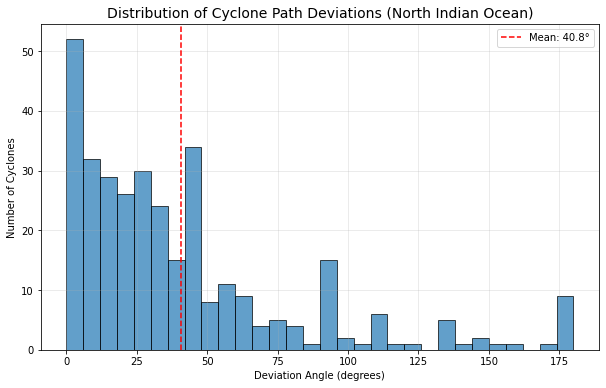

High deviations (>90°): 33 cyclones
Very high deviations (>120°): 21 cyclones


In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(deviations['deviation_deg'], bins=30, alpha=0.7, edgecolor='black')
plt.axvline(deviations['deviation_deg'].mean(), color='red', linestyle='--', 
            label='Mean: {:.1f}°'.format(deviations['deviation_deg'].mean()))
plt.title('Distribution of Cyclone Path Deviations (North Indian Ocean)', fontsize=14)
plt.xlabel('Deviation Angle (degrees)')
plt.ylabel('Number of Cyclones')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("High deviations (>90°):", (deviations['deviation_deg'] > 90).sum(), "cyclones")
print("Very high deviations (>120°):", (deviations['deviation_deg'] > 120).sum(), "cyclones")
